In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Create the house dataset
data = {
    'Age': [20, 15, 10, 12, 8, 5, 3, 1, 2, 0, 7],
    'Rooms': [2, 2, 3, 3, 3, 4, 4, 4, 5, 5, 4],
    'Price': [150000, 180000, 220000, 250000, 300000, 350000, 400000, 450000, 500000, 550000, None]
}

df = pd.DataFrame(data)
df

,Age,Rooms,Price
0,20,2,150000.0
1,15,2,180000.0
2,10,3,220000.0
3,12,3,250000.0
4,8,3,300000.0
5,5,4,350000.0
6,3,4,400000.0
7,1,4,450000.0
8,2,5,500000.0
9,0,5,550000.0


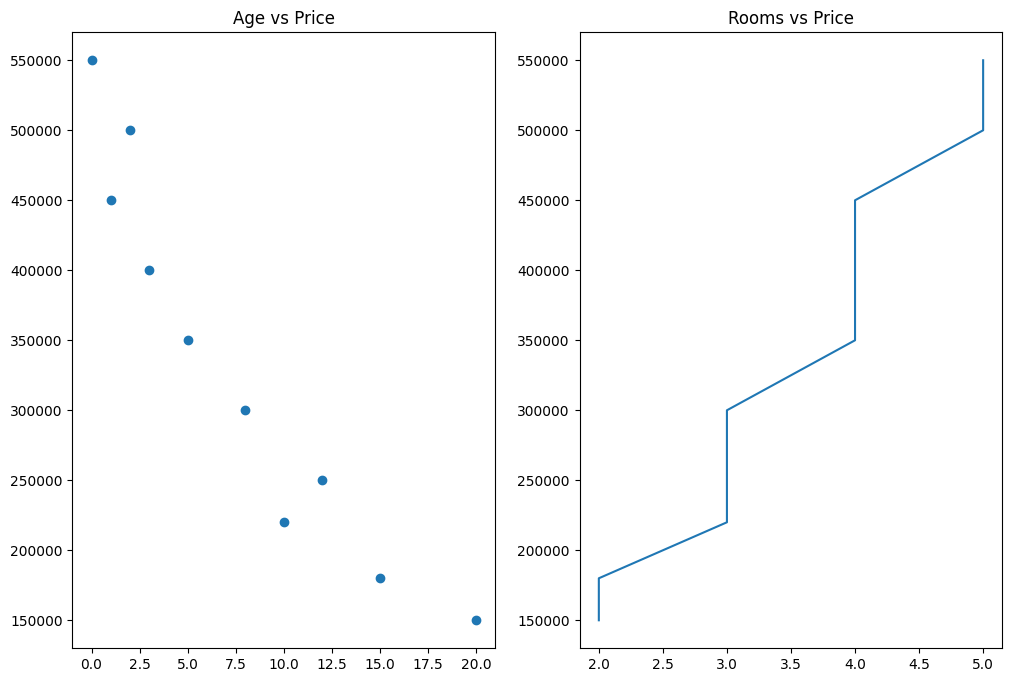

In [14]:
fig,axes=plt.subplots(1,2,figsize=(12,8))
plt.subplot(1,2,1)
plt.scatter(df['Age'],df['Price'])
plt.title('Age vs Price')
plt.subplot(1,2,2)  
plt.plot(df['Rooms'],df['Price'])
plt.title('Rooms vs Price')
plt.show()

In [3]:
# Check the dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Age     11 non-null     int64  
 1   Rooms   11 non-null     int64  
 2   Price   10 non-null     float64
dtypes: float64(1), int64(2)
memory usage: 396.0 bytes


In [4]:
# Separate the row with missing price because this is the house we want to predict
house_to_predict = df[df['Price'].isnull()]

# Drop rows with missing prices for training
train_df = df.dropna()
train_df

,Age,Rooms,Price
0,20,2,150000.0
1,15,2,180000.0
2,10,3,220000.0
3,12,3,250000.0
4,8,3,300000.0
5,5,4,350000.0
6,3,4,400000.0
7,1,4,450000.0
8,2,5,500000.0
9,0,5,550000.0


In [5]:
# Prepare data
# Age and Rooms are the independent variables
# Price is the dependent variable we want to predict
X = train_df[['Age', 'Rooms']]
y = train_df['Price']

In [6]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

In [7]:
# Select and train the model
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [8]:
# Make predictions using the test data
y_pred = model.predict(X_test)

In [9]:
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [10]:
# Output the results
print('--- Regression Results ---')
print(f'Predicted prices: {y_pred}')
print(f'Actual prices: {y_test.values}')
print(f'Mean Squared Error: {mse:.2f}')
print(f'R-squared Score: {r2:.2f}')

--- Regression Results ---
Predicted prices: [511340.57971014 143768.11594203]
Actual prices: [500000. 180000.]
Mean Squared Error: 720679085.28
R-squared Score: 0.97


In [ ]:
# Predict the price of the house with missing price
new_house = house_to_predict[['Age', 'Rooms']]
predicted_price = model.predict(new_house)

print('--- House Price Prediction ---')
print('House age:', house_to_predict['Age'].values[0])
print('Number of rooms:', house_to_predict['Rooms'].values[0])
print(f'Predicted house price: {predicted_price[0]:.2f}')

--- House Price Prediction ---
House age: 7
Number of rooms: 4
Predicted house price: 385144.93
